In [1]:
# ------------------------------------------------------------
# Notebook 03 — Model Training (Vibe Coding Style)
# BiofilmAI — Gene Expression → Biofilm Prediction
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

sns.set(style="whitegrid", palette="deep")


In [2]:
# ------------------------------------------------------------
# Step 1: Load engineered ML dataset
# ------------------------------------------------------------

df = pd.read_csv("../data/gene_expression/biofilm_ml_features_final.csv")
print("Loaded:", df.shape)
df.head()


Loaded: (7563, 34)


,id,gene_symbol,biofilm_logFC,log_CPM,deseq.p-value,biofilm_padj,edger.p.value,edger.adj.p.value,X3225B2.norm,X3225B3.norm,...,planktonic_abs_logFC,biofilm_significant,planktonic_significant,biofilm_label,logFC_interaction,abs_logFC_interaction,logFC_difference,abs_logFC_difference,logFC_ratio,abs_logFC_ratio
0,PA14_22460,PA14_22460,4.345,7.733,2.000000e-71,1.200000e-67,4.600000e-80,1.400000e-76,1686,1573,...,4.044,1,1,1,17.571180,17.571180,0.301,0.301,1.074431,1.074431
1,PA14_22450,ppiA,4.151,7.630,1.000000e-66,3.000000e-63,2.400000e-85,1.400000e-81,1574,1537,...,3.982,1,1,1,16.529282,16.529282,0.169,0.169,1.042441,1.042441
2,PA14_22470,PA14_22470,3.929,9.077,8.800000e-66,1.700000e-62,1.800000e-75,3.500000e-72,4458,3785,...,3.617,1,1,1,14.211193,14.211193,0.312,0.312,1.086259,1.086259
3,PA14_22440,bapA,3.773,8.996,3.000000e-62,4.400000e-59,1.100000e-73,1.600000e-70,3877,3928,...,3.418,1,1,1,12.896114,12.896114,0.355,0.355,1.103862,1.103862
4,PA14_27070,PA14_27070,3.263,9.016,1.400000e-49,1.600000e-46,2.100000e-53,2.500000e-50,4260,3546,...,3.031,1,1,1,9.890153,9.890153,0.232,0.232,1.076542,1.076542


In [6]:
# ------------------------------------------------------------
# Step 2: Define X (features) and y (target)
# ------------------------------------------------------------

X = df.drop(columns=["biofilm_label"])
y = df["biofilm_label"]

print("Features:", X.shape)
print("Target:", y.shape)


Features: (7563, 33)
Target: (7563,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [9]:
# ------------------------------------------------------------
# Fix: Drop non-numeric columns before scaling
# ------------------------------------------------------------

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

# Drop them
X = X.drop(columns=non_numeric_cols)

print("Updated feature shape:", X.shape)


Non-numeric columns: ['id', 'gene_symbol']
Updated feature shape: (7563, 31)


In [11]:
# ------------------------------------------------------------
# Fix: Drop non-numeric columns before scaling
# ------------------------------------------------------------

non_numeric_cols = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

X = X.drop(columns=non_numeric_cols)

print("Updated feature shape:", X.shape)


Non-numeric columns: []
Updated feature shape: (7563, 31)


In [12]:
# ------------------------------------------------------------
# Step 3: Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (5672, 31)
Test: (1891, 31)


In [13]:
# ------------------------------------------------------------
# Step 4: Scale features
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
# ------------------------------------------------------------
# Step 5: Logistic Regression
# ------------------------------------------------------------

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_scaled, y_train)

log_pred = log_reg.predict(X_test_scaled)
log_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training complete.")


Logistic Regression training complete.


In [15]:
# ------------------------------------------------------------
# Step 6: Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")


Random Forest training complete.


In [16]:
# ------------------------------------------------------------
# Step 7: Evaluation helper
# ------------------------------------------------------------

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance")
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))


In [17]:
# ------------------------------------------------------------
# Step 8: Evaluate both models
# ------------------------------------------------------------

evaluate_model("Logistic Regression", y_test, log_pred)
evaluate_model("Random Forest", y_test, rf_pred)



Logistic Regression Performance
----------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Random Forest Performance
----------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


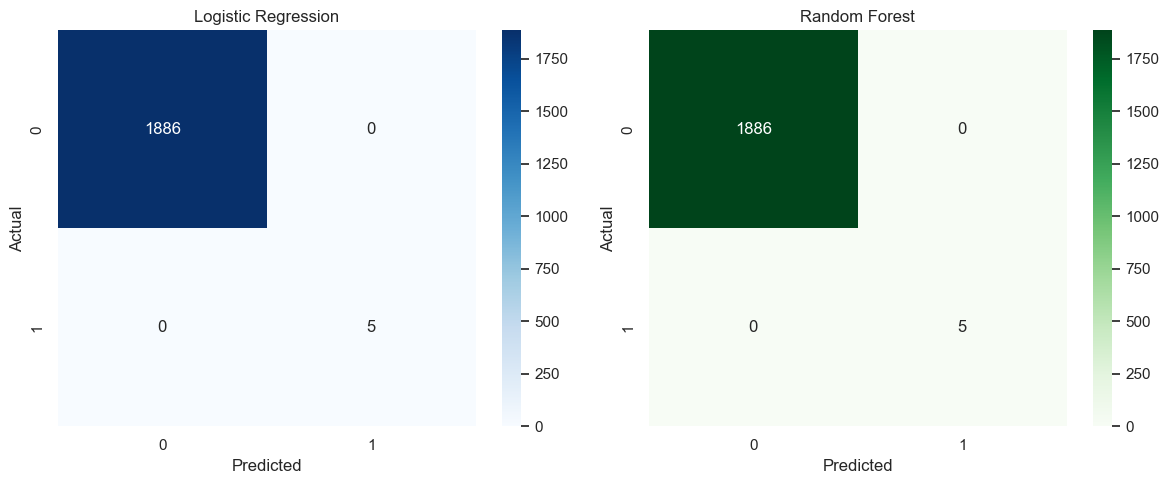

In [18]:
# ------------------------------------------------------------
# Step 9: Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True, fmt="d", cmap="Blues", ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True, fmt="d", cmap="Greens", ax=axes[1]
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


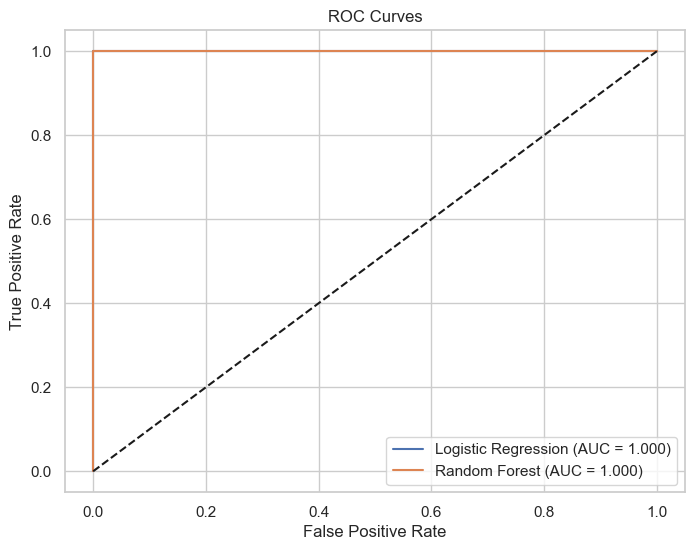

In [19]:
# ------------------------------------------------------------
# Step 10: ROC Curves
# ------------------------------------------------------------

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

log_auc = auc(log_fpr, log_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")  # diagonal baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
joblib.dump(best_model, f"../models/{best_name}.pkl")


['../models/logistic_regression.pkl']